In [25]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT.EnableImplicitMT(10)

Neste ficheiro vaise realizar un fit ao montecarlo das trazas Downstream para entender o comportamento do pico de masa dos samples tag e match, de forma que os resultados obtidos serán usados despois nos datos como parámetros iniciais do fit ou incluso algúns como parámetros fixados

Comezamos entón por ler os datos de MC

In [26]:
pathmc = '/rxc_lustre/ivan.cambon/TrackCalibmu_AA_tuples/MC/pO_2025/trackeffmu_pO_mc_2025.root'


tdf_mc = ROOT.RDataFrame("charmonium_mu_mu_Down_mup_Tag/DecayTree", pathmc)

Aplicamos os mesmos filtros que en data:

In [27]:
datamc = tdf_mc.Filter("dimuon_BPVIP < 0.35 && dimuon_DOCA_12 < 0.5 &&  dimuon_PT > 2000 && mum_CHI2DOF < 1.5 && mum_P > 1000 && mum_PID_MU > 0 && mum_PT > 1500 && mup_CHI2DOF < 1.2")
datamc = datamc.Filter("abs(dimuon_TRUEID)==443")

Definimos a variable sobre a que facer os fits (masa) e a continuación realízase o fit a unha Gaussiana + CB

In [28]:
mass = ROOT.RooRealVar("dimuon_M", "m(#mu^+#mu^-)", 3000, 3200) 
data = datamc.AsNumpy(["dimuon_M"])
roo_data = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data["dimuon_M"]},
    [mass]
)


[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 669 out-of-range events


In [29]:
# 1. Variables do sinal
mean   = ROOT.RooRealVar("mean", "mean", 3096, 3070, 3130)
sigma1 = ROOT.RooRealVar("sigma1", "sigma gauss", 8, 2, 30)  # O núcleo estreito
sigma2 = ROOT.RooRealVar("sigma2", "sigma cb", 25, 15, 80)   # As colas
alpha  = ROOT.RooRealVar("alpha", "alpha", 1.5, 0.1, 10)
n      = ROOT.RooRealVar("n", "n", 3, -5, 100)               

# 2. Funcións do sinal
gauss = ROOT.RooGaussian("gauss", "Gaussian Core", mass, mean, sigma1)
cb    = ROOT.RooCBShape("cb", "Crystal Ball Tail", mass, mean, sigma2, alpha, n)

sig_frac = ROOT.RooRealVar("sig_frac", "fraction Gauss/CB", 0.5, 0, 1)

# Creamos o pdf do sinal combinado
signal = ROOT.RooAddPdf("signal", "Gauss + CB", [gauss, cb], [sig_frac])
#Fiteamos
signal.fitTo(roo_data)


<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss,cb)
 **********
 **   28 **SET PRINT           1
 **********
 **********
 **   29 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 alpha        1.50000e+00  7.00000e-01    1.00000e-01  1.00000e+01
     2 mean         3.09600e+03  6.00000e+00    3.07000e+03  3.13000e+03
     3 n            3.00000e+00  4.00000e+00   -5.00000e+00  1.00000e+02
     4 sig_frac     5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     5 sigma1       8.00000e+00  2.80000e+00    2.00000e+00  3.00000e+01
     6 sigma2       2.50000e+01  5.00000e+00    1.50000e+01  8.00000e+01
 **********
 **   30 **SET ERR         0.5
 **********
 **********
 **   31 **SET PRINT           1
 **********
 **********
 **   32 **SET STR           1
 **********
 NOW USING 

Facemos o plot dos resultados para comprobar visualmente

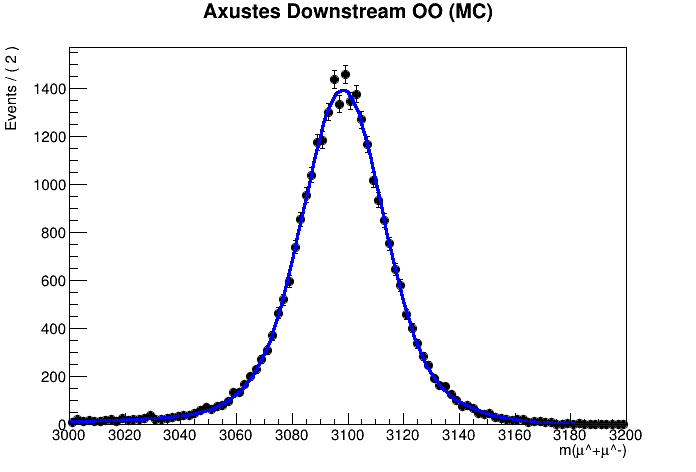

In [32]:
frame = mass.frame()

roo_data.plotOn(frame)
signal.plotOn(frame)   # ou gauss

c = ROOT.TCanvas()
frame.SetTitle("")
frame.Draw()
title_text = ROOT.TLatex()
title_text.SetNDC()              # Usa coordenadas da pantalla (0 a 1) no canto das dos eixes
title_text.SetTextSize(0.045)    # Tamaño do texto
title_text.SetTextFont(62)       # Tipo de letra (62 adoita ser negrita en ROOT)
title_text.SetTextAlign(21)      # Aliñación: 2 (centro horizontal), 1 (abaixo vertical)

# Debuxamos o título na posición X=0.5 (centro) e Y=0.92 (arriba do todo)
title_text.DrawLatex(0.5, 0.96, "Axustes Downstream OO (MC)")
c.Draw()